### Twitter Sntiment Analysis using Bernoulli Naive Bayes, SVM, and Logistic Regression in Sklearn
we can track the feeling of people by their post on twitter, how do they feel based on that we can make decission.

##### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Loading Dataset

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Sentiment140 has no header and is encoded as latin-1
columns = ["target", "ids", "date", "flag", "user", "text"]
file_path = "training.1600000.processed.noemoticon.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kazanova/sentiment140",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1",
        "header": None,
        "names": columns,
    },
)

df.head()

Using Colab cache for faster access to the 'sentiment140' dataset.


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
X = df.iloc[:, -1]
y = df.iloc[:, 0]

In [4]:
y.value_counts()

,count
target,
0,800000
4,800000


In [5]:
# Convert labels: 0 -> 0 (negative), 4 -> 1 (positive)
# y = (y == 4).astype(int)
y = y.map({0:0, 4:1})
y.value_counts()

,count
target,
0,800000
1,800000


##### 3. Clean the twittes

In [6]:
X.head()

,text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,is upset that he can't update his Facebook by ...
2,@Kenichan I dived many times for the ball. Man...
3,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all...."


In [7]:
X.values

array(["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D",
       "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
       '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
       ..., 'Are you ready for your MoJo Makeover? Ask me for details ',
       'Happy 38th Birthday to my boo of alll time!!! Tupac Amaru Shakur ',
       'happy #charitytuesday @theNSPCC @SparksCharity @SpeakingUpH4H '],
      dtype=object)

In [8]:
# 1) convert the text to lowercase, remove punctuation, numbers, special characters and HTML tags.
import re
import string

def clean(text):
    text = text.lower() # lowercasing the text
    text = re.sub(r'<[^>]+>', '', text) # Remove HTML Tags (fast regex instead of BeautifulSoup)
    text = re.sub(r'\d+', '', text) # Removing Numbers or digits
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\W', ' ', text) # Remove Spatial Characters
    return text.strip()

text = [clean(i) for i in X]
text

['switchfoot httptwitpiccomyzl  awww thats a bummer  you shoulda got david carr of third day to do it d',
 'is upset that he cant update his facebook by texting it and might cry as a result  school today also blah',
 'kenichan i dived many times for the ball managed to save   the rest go out of bounds',
 'my whole body feels itchy and like its on fire',
 'nationwideclass no its not behaving at all im mad why am i here because i cant see you all over there',
 'kwesidei not the whole crew',
 'need a hug',
 'loltrish hey  long time no see yes rains a bit only a bit  lol  im fine thanks  hows you',
 'tatianak nope they didnt have it',
 'twittera que me muera',
 'spring break in plain city its snowing',
 'i just repierced my ears',
 'caregiving i couldnt bear to watch it  and i thought the ua loss was embarrassing',
 'octolinz it it counts idk why i did either you never talk to me anymore',
 'smarrison i wouldve been the first but i didnt have a gun    not really though zac snyders just a d

In [9]:
# 2) Tokenization
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')
text = [word_tokenize(i) for i in text]
text

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[['switchfoot',
  'httptwitpiccomyzl',
  'awww',
  'thats',
  'a',
  'bummer',
  'you',
  'shoulda',
  'got',
  'david',
  'carr',
  'of',
  'third',
  'day',
  'to',
  'do',
  'it',
  'd'],
 ['is',
  'upset',
  'that',
  'he',
  'cant',
  'update',
  'his',
  'facebook',
  'by',
  'texting',
  'it',
  'and',
  'might',
  'cry',
  'as',
  'a',
  'result',
  'school',
  'today',
  'also',
  'blah'],
 ['kenichan',
  'i',
  'dived',
  'many',
  'times',
  'for',
  'the',
  'ball',
  'managed',
  'to',
  'save',
  'the',
  'rest',
  'go',
  'out',
  'of',
  'bounds'],
 ['my', 'whole', 'body', 'feels', 'itchy', 'and', 'like', 'its', 'on', 'fire'],
 ['nationwideclass',
  'no',
  'its',
  'not',
  'behaving',
  'at',
  'all',
  'im',
  'mad',
  'why',
  'am',
  'i',
  'here',
  'because',
  'i',
  'cant',
  'see',
  'you',
  'all',
  'over',
  'there'],
 ['kwesidei', 'not', 'the', 'whole', 'crew'],
 ['need', 'a', 'hug'],
 ['loltrish',
  'hey',
  'long',
  'time',
  'no',
  'see',
  'yes',
  '

In [10]:
# 3) Stop words Removal
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

text = [[word for word in i if word not in stop_words] for i in text]
text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[['switchfoot',
  'httptwitpiccomyzl',
  'awww',
  'thats',
  'bummer',
  'shoulda',
  'got',
  'david',
  'carr',
  'third',
  'day'],
 ['upset',
  'cant',
  'update',
  'facebook',
  'texting',
  'might',
  'cry',
  'result',
  'school',
  'today',
  'also',
  'blah'],
 ['kenichan',
  'dived',
  'many',
  'times',
  'ball',
  'managed',
  'save',
  'rest',
  'go',
  'bounds'],
 ['whole', 'body', 'feels', 'itchy', 'like', 'fire'],
 ['nationwideclass', 'behaving', 'im', 'mad', 'cant', 'see'],
 ['kwesidei', 'whole', 'crew'],
 ['need', 'hug'],
 ['loltrish',
  'hey',
  'long',
  'time',
  'see',
  'yes',
  'rains',
  'bit',
  'bit',
  'lol',
  'im',
  'fine',
  'thanks',
  'hows'],
 ['tatianak', 'nope', 'didnt'],
 ['twittera', 'que', 'muera'],
 ['spring', 'break', 'plain', 'city', 'snowing'],
 ['repierced', 'ears'],
 ['caregiving',
  'couldnt',
  'bear',
  'watch',
  'thought',
  'ua',
  'loss',
  'embarrassing'],
 ['octolinz', 'counts', 'idk', 'either', 'never', 'talk', 'anymore'],
 ['sm

In [11]:
# 4) Stemming and Lemmatization
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

text = [[stemmer.stem(word) for word in doc] for doc in text]
text = [[lemmatizer.lemmatize(word) for word in doc] for doc in text]
text

[nltk_data] Downloading package wordnet to /root/nltk_data...


[['switchfoot',
  'httptwitpiccomyzl',
  'awww',
  'that',
  'bummer',
  'shoulda',
  'got',
  'david',
  'carr',
  'third',
  'day'],
 ['upset',
  'cant',
  'updat',
  'facebook',
  'text',
  'might',
  'cri',
  'result',
  'school',
  'today',
  'also',
  'blah'],
 ['kenichan',
  'dive',
  'mani',
  'time',
  'ball',
  'manag',
  'save',
  'rest',
  'go',
  'bound'],
 ['whole', 'bodi', 'feel', 'itchi', 'like', 'fire'],
 ['nationwideclass', 'behav', 'im', 'mad', 'cant', 'see'],
 ['kwesidei', 'whole', 'crew'],
 ['need', 'hug'],
 ['loltrish',
  'hey',
  'long',
  'time',
  'see',
  'ye',
  'rain',
  'bit',
  'bit',
  'lol',
  'im',
  'fine',
  'thank',
  'how'],
 ['tatianak', 'nope', 'didnt'],
 ['twittera', 'que', 'muera'],
 ['spring', 'break', 'plain', 'citi', 'snow'],
 ['repierc', 'ear'],
 ['caregiv', 'couldnt', 'bear', 'watch', 'thought', 'ua', 'loss', 'embarrass'],
 ['octolinz', 'count', 'idk', 'either', 'never', 'talk', 'anymor'],
 ['smarrison',
  'wouldv',
  'first',
  'didnt',
  

In [16]:
# 5) Join tokens back to strings before vectorization
text = [' '.join(tokens) for tokens in text]

##### 4. Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    text,
    y,
    test_size=0.2,
    random_state=42
)

##### 6. Perform Vectorization

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

##### 7.Build the Models

In [22]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Create individual models
bnb = BernoulliNB()
svm = LinearSVC(max_iter=2000)
lr = LogisticRegression(max_iter=2000)

In [23]:
# Fit models and Evaluate them
print("Bernoulli Naive Bayes Score:", bnb.fit(X_train, y_train).score(X_test, y_test))
print("Linear SVM Score:", svm.fit(X_train, y_train).score(X_test, y_test))
print("Logistic Regression Score:", lr.fit(X_train, y_train).score(X_test, y_test))

Bernoulli Naive Bayes Score: 0.77053125
Linear SVM Score: 0.77456875
Logistic Regression Score: 0.781259375


##### 8. Make prediction

In [24]:
# Sample tweets for prediction
sample_tweets = ["I love this!", "I hate that!", "It was okay, not great."]

# Clean the sample tweets using the same cleaning function
cleaned_tweets = [clean(tweet) for tweet in sample_tweets]

# Tokenize
cleaned_tweets = [word_tokenize(tweet) for tweet in cleaned_tweets]

# Remove stop words
cleaned_tweets = [[word for word in tweet if word not in stop_words] for tweet in cleaned_tweets]

# Stem and lemmatize
cleaned_tweets = [[stemmer.stem(word) for word in tweet] for tweet in cleaned_tweets]
cleaned_tweets = [[lemmatizer.lemmatize(word) for word in tweet] for tweet in cleaned_tweets]

# Join tokens back to strings
cleaned_tweets = [' '.join(tokens) for tokens in cleaned_tweets]

# Vectorize using the same vectorizer
sample_vectors = vectorizer.transform(cleaned_tweets)

# Make predictions with all three models
print("Sample Tweets Predictions:")
print("=" * 60)
for i, tweet in enumerate(sample_tweets):
    print(f"\nTweet {i+1}: '{tweet}'")
    print(f"  Bernoulli NB: {'Positive' if bnb.predict(sample_vectors[i])[0] == 1 else 'Negative'}")
    print(f"  Linear SVM:   {'Positive' if svm.predict(sample_vectors[i])[0] == 1 else 'Negative'}")
    print(f"  Logistic Reg: {'Positive' if lr.predict(sample_vectors[i])[0] == 1 else 'Negative'}")

Sample Tweets Predictions:

Tweet 1: 'I love this!'
  Bernoulli NB: Positive
  Linear SVM:   Positive
  Logistic Reg: Positive

Tweet 2: 'I hate that!'
  Bernoulli NB: Negative
  Linear SVM:   Negative
  Logistic Reg: Negative

Tweet 3: 'It was okay, not great.'
  Bernoulli NB: Positive
  Linear SVM:   Positive
  Logistic Reg: Positive


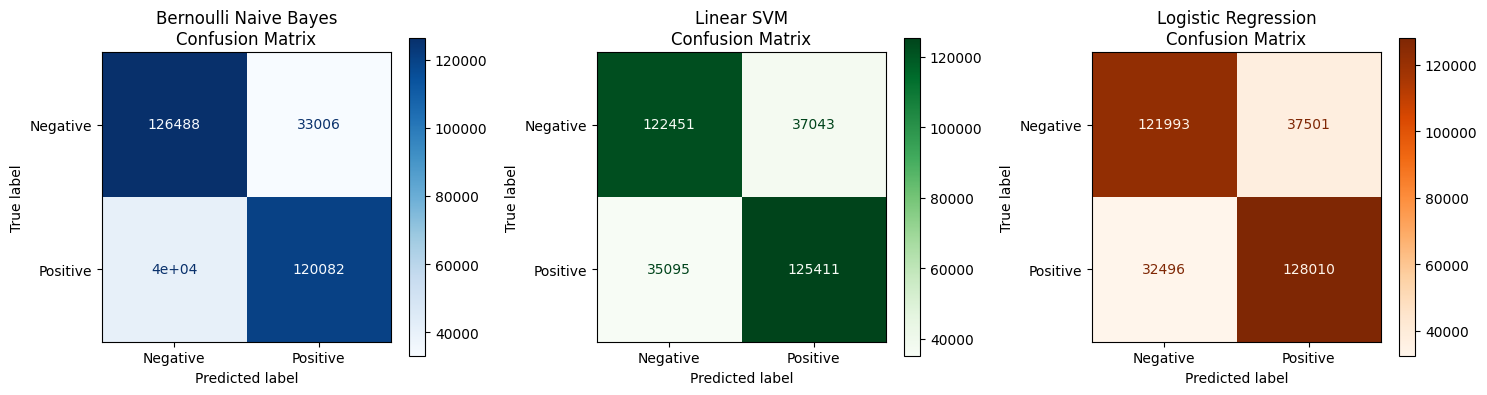

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create predictions on test set for all three models
bnb_pred = bnb.predict(X_test)
svm_pred = svm.predict(X_test)
lr_pred = lr.predict(X_test)

# Create confusion matrices
bnb_cm = confusion_matrix(y_test, bnb_pred)
svm_cm = confusion_matrix(y_test, svm_pred)
lr_cm = confusion_matrix(y_test, lr_pred)

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot confusion matrices
ConfusionMatrixDisplay(bnb_cm, display_labels=['Negative', 'Positive']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Bernoulli Naive Bayes\nConfusion Matrix')

ConfusionMatrixDisplay(svm_cm, display_labels=['Negative', 'Positive']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Linear SVM\nConfusion Matrix')

ConfusionMatrixDisplay(lr_cm, display_labels=['Negative', 'Positive']).plot(ax=axes[2], cmap='Oranges')
axes[2].set_title('Logistic Regression\nConfusion Matrix')

plt.tight_layout()
plt.show()

Bernoulli NB:
  Training Accuracy: 0.8334
  Test Accuracy:     0.7705

Linear SVM:
  Training Accuracy: 0.8843
  Test Accuracy:     0.7746

Logistic Regression:
  Training Accuracy: 0.8084
  Test Accuracy:     0.7813



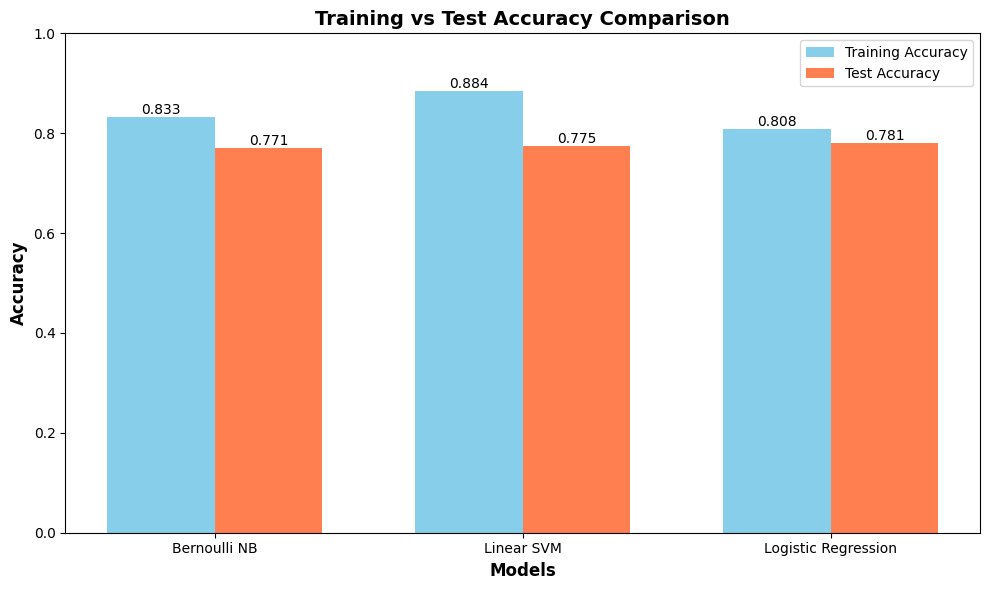

In [26]:
# Calculate training and test accuracy for all models
models_info = {
    'Bernoulli NB': bnb,
    'Linear SVM': svm,
    'Logistic Regression': lr
}

train_scores = []
test_scores = []
model_names = []

for name, model in models_info.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    model_names.append(name)
    
    print(f"{name}:")
    print(f"  Training Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy:     {test_score:.4f}")
    print()

# Plot training vs test accuracy
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_scores, width, label='Training Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', color='coral')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()